# ECG5000 Dataset Visualisation

This notebook loads the ECG5000 dataset and visualises:

- the dataset shapes
- one ECG recording
- one ECG example from each class
- several examples within each class
- the train/test class distribution


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


## 1. Load the ECG5000 data

Each row contains:

`[class label, sample_1, sample_2, ..., sample_140]`


In [7]:
# Change this path if your notebook is stored somewhere else
data_dir = Path(r'C:\Users\Yovel\Documents\pytorch_project\DL_TimeSeries_SummerSchool\projects\ecg5000\data'
)

train_path = data_dir / 'ECG5000_TRAIN.txt'
test_path = data_dir / 'ECG5000_TEST.txt'

train_data = np.loadtxt(train_path)
test_data = np.loadtxt(test_path)

print('Raw training shape:', train_data.shape)
print('Raw test shape:', test_data.shape)


Raw training shape: (500, 141)
Raw test shape: (4500, 141)


## 2. Separate signals and labels

- Column 0 = class label
- Columns 1 to 140 = ECG waveform samples


In [8]:
# Labels
y_train = train_data[:, 0].astype(int)
y_test = test_data[:, 0].astype(int)

# ECG signals
X_train = train_data[:, 1:].astype(np.float32)
X_test = test_data[:, 1:].astype(np.float32)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)
print('Classes:', np.unique(y_train))


X_train: (500, 140)
y_train: (500,)
X_test: (4500, 140)
y_test: (4500,)
Classes: [1 2 3 4 5]


## 3. Look at one ECG recording

Each recording has 140 time samples.


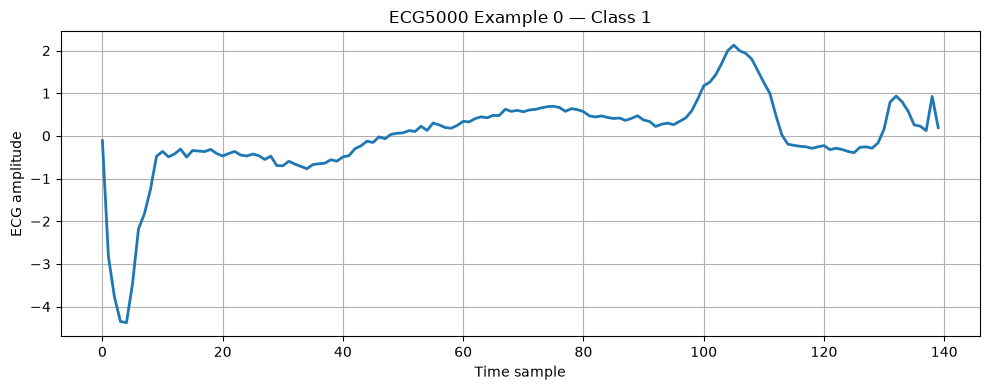

In [9]:
example_index = 0
samples = np.arange(X_train.shape[1])

plt.figure(figsize=(10, 4))
plt.plot(samples, X_train[example_index], linewidth=2)
plt.title(f'ECG5000 Example {example_index} — Class {y_train[example_index]}')
plt.xlabel('Time sample')
plt.ylabel('ECG amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()


## 4. Compare one ECG from each class

This is useful for seeing how the waveform shapes differ between the five classes.


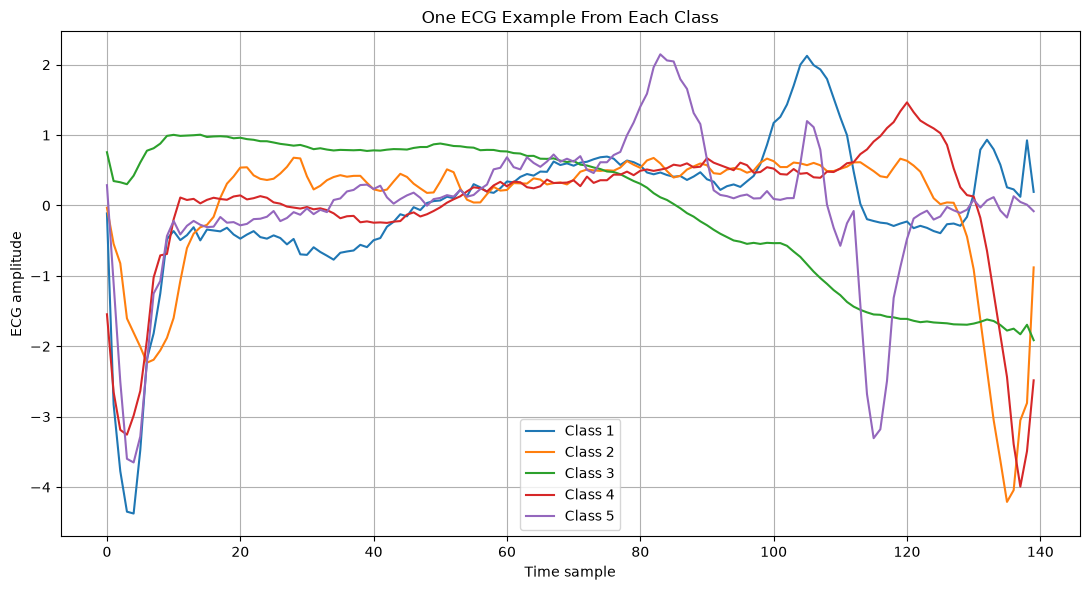

In [10]:
classes = np.unique(y_train)

plt.figure(figsize=(11, 6))

for class_label in classes:
    index = np.where(y_train == class_label)[0][0]
    plt.plot(samples, X_train[index], linewidth=1.5, label=f'Class {class_label}')

plt.title('One ECG Example From Each Class')
plt.xlabel('Time sample')
plt.ylabel('ECG amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Look at several ECGs from a chosen class

Change `class_to_view` to 1, 2, 3, 4, or 5.


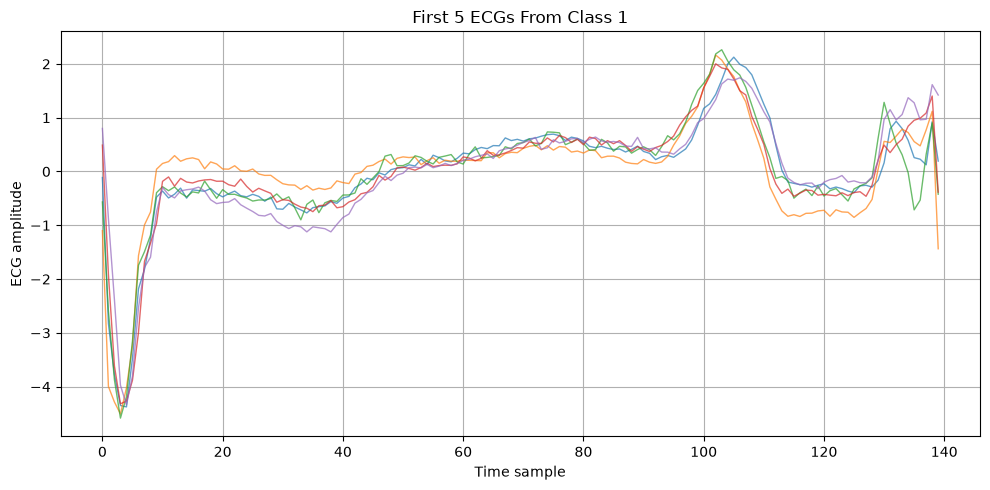

In [11]:
class_to_view = 1

indices = np.where(y_train == class_to_view)[0]

plt.figure(figsize=(10, 5))

for index in indices[:5]:
    plt.plot(samples, X_train[index], linewidth=1, alpha=0.7)

plt.title(f'First 5 ECGs From Class {class_to_view}')
plt.xlabel('Time sample')
plt.ylabel('ECG amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Class distribution

This shows how many ECG examples belong to each class in the train and test datasets.


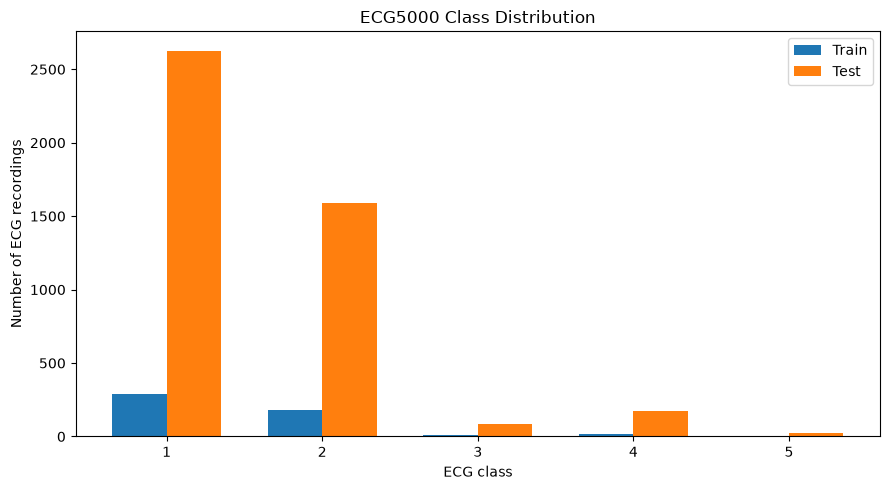

In [12]:
train_classes, train_counts = np.unique(y_train, return_counts=True)
test_classes, test_counts = np.unique(y_test, return_counts=True)

x = np.arange(len(train_classes))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, train_counts, width, label='Train')
plt.bar(x + width / 2, test_counts, width, label='Test')

plt.xticks(x, train_classes)
plt.xlabel('ECG class')
plt.ylabel('Number of ECG recordings')
plt.title('ECG5000 Class Distribution')
plt.legend()
plt.tight_layout()
plt.show()
